Extracting and calculating metrics...
wrote /home/ubuntu/clean/bench360/ACL-IE-Energy/figures/pareto_e2e_stacked.pdf

VRDU frontier (zero-shot models only):
  Model                Configuration                   E2E (Wh) = Inf (Wh) + OCR (Wh) | EM (%)
  -------------------------------------------------------------------------------------------
  Qwen3-0.6B           Text-only + Tesseract             0.0130 =   0.0033 +   0.0097 |   39.1
  Qwen3-VL-2B          Vision-language (no parser)       0.0144 =   0.0144 +   0.0000 |   65.1
  Qwen3-VL-4B          Vision-language (no parser)       0.0222 =   0.0222 +   0.0000 |   65.6
  NuExtract-2.0-4B     NuExtract-2.0-4B                  0.0327 =   0.0327 +   0.0000 |   78.3

Kleister-NDA frontier (zero-shot models only):
  Model                Configuration                   E2E (Wh) = Inf (Wh) + OCR (Wh) | EM (%)
  -------------------------------------------------------------------------------------------
  Qwen3-0.6B           Text-only + Do

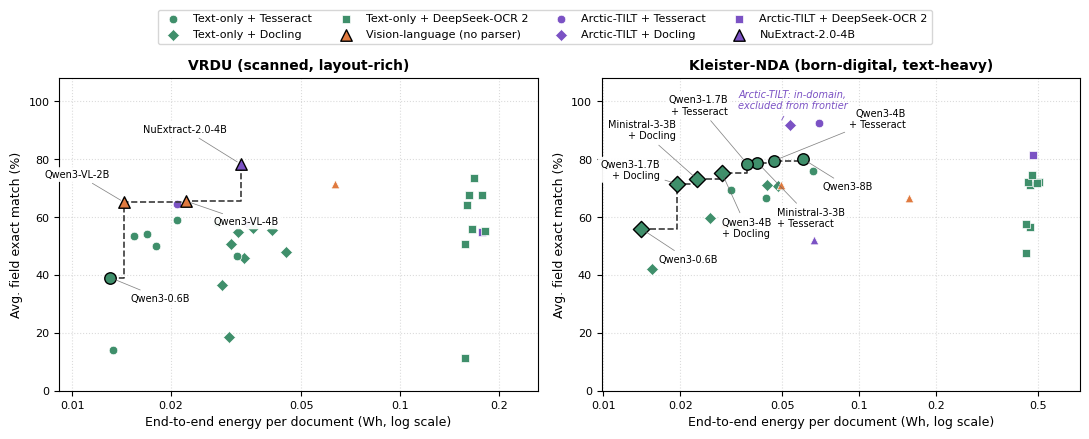

In [41]:
"""Regenerate the end-to-end Pareto figure for the paper (figures/pareto_e2e_stacked.pdf)."""

import os
import io
import glob
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, NullFormatter, NullLocator

SRC = Path.cwd().parent
OUT = SRC / "ACL-IE-Energy" / "figures" / "pareto_e2e_stacked.pdf"

# ==========================================
# 1. DATA EXTRACTION AND PROCESSING LOGIC
# ==========================================

def get_ocr_energy_per_doc(dataset_name="VRDU", task_name="tesseract"):
    """Calculates the OCR energy per document from the respective OCR reports."""
    base_path = '../benchmark/ocr_profiling/report/'
    try:
        if dataset_name == "VRDU":
            if task_name == "tesseract":
                df_ocr = pd.read_csv(f'{base_path}tesseract_vrdu.csv')
                wh_total = float(df_ocr['Total Energy Consumed (kWh)'].iloc[0]) * 1000
            elif task_name == "docling":
                df_ocr = pd.read_csv(f'{base_path}docling_vrdu.csv')
                wh_total = float(df_ocr[df_ocr['Metric'] == 'Energy Consumed (kWh)']['Value'].values[0]) * 1000
            elif task_name == "deepseek":
                df_ocr = pd.read_csv(f'{base_path}deepseek_vrdu_report_bs10.csv')
                wh_total = float(df_ocr[df_ocr['Metric'] == 'Energy Consumed (kWh)']['Value'].values[0]) * 1000
            else:
                return 0.0
            return wh_total / 500

        if dataset_name == "Kleister NDA":
            if task_name == "tesseract":
                df_ocr = pd.read_csv(f'{base_path}tesseract_kleister.csv')
            elif task_name == "docling":
                df_ocr = pd.read_csv(f'{base_path}docling_kleister.csv')
            elif task_name == "deepseek":
                df_ocr = pd.read_csv(f'{base_path}deepseek_kleister_bs5.csv')
            else:
                return 0.0
            wh_total = float(df_ocr[df_ocr['Metric'] == 'Energy Consumed (kWh)']['Value'].values[0]) * 1000
            return wh_total / 500
    except Exception:
        return 0.0
    return 0.0


def load_cleaned_energy_report(filepath):
    """Reads the CSV, adds a batch_size column, and aligns all rows."""
    if not os.path.exists(filepath):
        return pd.DataFrame()
    with open(filepath, 'r') as file:
        lines = file.readlines()
    if not lines:
        return pd.DataFrame()
    header = lines[0].strip('\n').split(',')
    if header[1] != 'batch_size':
        header.insert(1, 'batch_size')
    cleaned_lines = [','.join(header) + '\n']
    for line in lines[1:]:
        parts = line.strip('\n').split(',')
        if len(parts) == 39:
            parts.insert(1, '1')
        elif len(parts) > 40:
            parts = parts[:40]
        cleaned_lines.append(','.join(parts) + '\n')
    return pd.read_csv(io.StringIO(''.join(cleaned_lines)))


def parse_standard_report(file_path):
    """Parses a single standard run report CSV and returns extracted metrics."""
    df_temp = pd.read_csv(file_path)
    model_name = df_temp['model_name'].iloc[0] if 'model_name' in df_temp.columns else "unknown"
    batch_size = df_temp['batch_size'].iloc[0] if 'batch_size' in df_temp.columns else 1
    energy = df_temp['total_energy_wh'].iloc[0] if 'total_energy_wh' in df_temp.columns else 0.0

    if 'avg_calculated_field_em' in df_temp.columns:
        exact_match = df_temp['avg_calculated_field_em'].iloc[0] * 100
    else:
        exact_match = df_temp['avg_field_em'].iloc[0] * 100 if 'avg_field_em' in df_temp.columns else 0.0

    if 'avg_calculated_fuzzy_score' in df_temp.columns:
        fuzzy_match = df_temp['avg_calculated_fuzzy_score'].iloc[0] * 100
    elif 'avg_avg_fuzzy_score' in df_temp.columns:
        fuzzy_match = df_temp['avg_avg_fuzzy_score'].iloc[0] * 100
    else:
        fuzzy_match = 0.0

    if 'avg_calculated_document_f1' in df_temp.columns:
        f1_score = df_temp['avg_calculated_document_f1'].iloc[0] * 100
    else:
        f1_score = df_temp['avg_field_f1'].iloc[0] * 100 if 'avg_field_f1' in df_temp.columns else 0.0

    dataset = "VRDU" if "vrdu" in file_path else "Kleister NDA"
    modality = "Vision" if "vrdu_vision" in file_path or "kleister_nda_vl" in file_path else "Text-Only"

    if "deepseek" in file_path:
        task = "deepseek"
    elif "docling" in file_path:
        task = "docling"
    elif "tesseract" in file_path:
        task = "tesseract"
    elif modality == "Vision":
        task = "vision"
    else:
        task = "default"

    return {
        'Dataset': dataset, 'Model': model_name, 'Batch_Size': batch_size,
        'Exact_Match': exact_match, 'Fuzzy_Match': fuzzy_match, 'F1_Score': f1_score,
        'Energy_Wh': energy, 'Modality': modality, 'Task': task, 'File_Path': file_path
    }


def load_all_data():
    """Unifies standard reports and standalone benchmarks into one DataFrame."""
    data_list = []
    standard_paths = [
        "../vrdu_noquant/run_report/*.csv",
        "../vrdu_quant/run_report/*.csv",
        "../vrdu_vision_noquant/run_report/*.csv",
        "../vrdu_vision_quant/run_report/*.csv",
        "../kleister_nda_noquant/run_report/*.csv",
        "../kleister_nda_quant/run_report/*.csv",
        "../kleister_nda_vl_noquant/run_report/*.csv",
        "../kleister_nda_vl_quant/run_report/*.csv",
    ]
    for path in standard_paths:
        for file in glob.glob(path):
            try:
                data_list.append(parse_standard_report(file))
            except Exception:
                pass

    arctic_dir = "../arctic_results/"
    inference_energy_path = "../arctic_results/inference_energy_report_pareto.csv"
    if os.path.exists(arctic_dir):
        try:
            energy_df = load_cleaned_energy_report(inference_energy_path)
            for file in glob.glob(os.path.join(arctic_dir, "evaluation_*.csv")):
                filename = os.path.basename(file)
                df_eval = pd.read_csv(file)
                metric_col = 'Metric / Entity Key' if 'Metric / Entity Key' in df_eval.columns else 'Entity Key / Metric'
                score_col = 'F1 Score' if 'F1 Score' in df_eval.columns else 'Fuzzy Match'

                em_row = df_eval[df_eval[metric_col].isin(['Average Field EM', 'avg_calculated_field_em']) |
                                 df_eval[metric_col].str.contains('Field EM|Exact Match|field_em', case=False, na=False)]
                em_row = em_row[~em_row[metric_col].str.contains('Subset', case=False, na=False)]
                exact_match = em_row[score_col].dropna().iloc[0] * 100 if not em_row.empty else 0.0
                fuzzy_row = df_eval[df_eval[metric_col].str.contains('Fuzzy|fuzzy_score', case=False, na=False)]
                fuzzy_match = fuzzy_row[score_col].dropna().iloc[0] * 100 if not fuzzy_row.empty else 0.0
                f1_row = df_eval[df_eval[metric_col].str.contains('Document F1|Field F1|document_f1', case=False, na=False)]
                f1_score = f1_row[score_col].dropna().iloc[0] * 100 if not f1_row.empty else 0.0

                dataset = "VRDU" if "vrdu" in filename else "Kleister NDA"
                search_ds = "vrdu" if "vrdu" in filename else "kleister"
                if "docling" in filename:
                    task, search_task = "docling", "docling"
                elif "tesseract" in filename:
                    task, search_task = "tesseract", "tesseract"
                elif "deepseek" in filename:
                    task, search_task = "deepseek", "deepseek"
                elif "baseline" in filename:
                    task, search_task = "default", "default"
                else:
                    task, search_task = "default", ("registration" if "vrdu" in filename else "ready")

                energy_wh = 0.0
                if not energy_df.empty and 'dataset_name' in energy_df.columns:
                    mask = (energy_df['dataset_name'].str.contains(search_ds, case=False, na=False) &
                            energy_df['dataset_name'].str.contains(search_task, case=False, na=False))
                    energy_match = energy_df[mask]
                    if not energy_match.empty:
                        energy_wh = energy_match['energy_consumed'].iloc[0] * 1000

                for bs_config in [1, 10]:
                    data_list.append({
                        'Dataset': dataset, 'Model': 'Arctic-TILT', 'Batch_Size': bs_config,
                        'Exact_Match': exact_match, 'Fuzzy_Match': fuzzy_match, 'F1_Score': f1_score,
                        'Energy_Wh': energy_wh, 'Modality': 'Text-Only', 'Task': task, 'File_Path': file
                    })
        except Exception:
            pass

    nuextract_configs = [
        {'path': '../benchmark/nuextract_vrdu/nuextract_vrdu_metrics.csv', 'dataset': 'VRDU'},
        {'path': '../benchmark/nuextract_kleister/kleister_standalone_metrics_output.csv', 'dataset': 'Kleister NDA'}
    ]
    for cfg in nuextract_configs:
        if os.path.exists(cfg['path']):
            try:
                df_nu = pd.read_csv(cfg['path'])
                exact_match = df_nu['avg_calculated_field_em'].iloc[0] * 100 if 'avg_calculated_field_em' in df_nu.columns else df_nu['avg_field_em'].iloc[0] * 100
                f1_score = df_nu['avg_calculated_document_f1'].iloc[0] * 100 if 'avg_calculated_document_f1' in df_nu.columns else df_nu.get('avg_field_f1', pd.Series([0.0])).iloc[0] * 100
                if 'avg_calculated_fuzzy_score' in df_nu.columns:
                    fuzzy_match = df_nu['avg_calculated_fuzzy_score'].iloc[0] * 100
                elif 'avg_avg_fuzzy_score' in df_nu.columns:
                    fuzzy_match = df_nu['avg_avg_fuzzy_score'].iloc[0] * 100
                else:
                    fuzzy_match = 0.0
                data_list.append({
                    'Model': 'NuExtract-2.0-4B', 'Dataset': cfg['dataset'], 'Modality': 'Vision',
                    'Exact_Match': exact_match, 'Fuzzy_Match': fuzzy_match, 'F1_Score': f1_score,
                    'Energy_Wh': df_nu['total_energy_wh'].iloc[0], 'Batch_Size': 1,
                    'Task': 'vision', 'File_Path': cfg['path']
                })
            except Exception:
                pass

    df_all = pd.DataFrame(data_list)
    if not df_all.empty:
        df_all['Batch_Size'] = pd.to_numeric(df_all['Batch_Size']).fillna(1)
    return df_all


def categorize_model(row):
    modality, task, model_name = str(row['Modality']), str(row['Task']).lower(), str(row['Model']).lower()
    is_arctic = 'arctic-tilt' in model_name
    if 'nuextract' in model_name:
        return 'nuextract'
    if modality == 'Vision' and not is_arctic:
        return 'vision'
    if modality == 'Text-Only' or is_arctic:
        prefix = 'arctic' if is_arctic else 'text'
        if task == 'docling':
            return f'{prefix}-doc'
        if task == 'deepseek':
            return f'{prefix}-ds'
        return f'{prefix}-tess'
    return 'other'


def process_dataset(df_all, target_dataset):
    if df_all.empty or 'Dataset' not in df_all.columns:
        print(f"⚠️ Warning: No data found for {target_dataset}. Please verify your CSV file paths.")
        return []
    df_plot = df_all[df_all['Dataset'] == target_dataset].copy()

    def is_unquantized(path):
        path_str = str(path).lower()
        return 'noquant' in path_str or 'quant' not in path_str

    df_plot = df_plot[df_plot['File_Path'].apply(is_unquantized)].copy()
    test_set_sizes = {'VRDU': 500, 'Kleister NDA': 337}

    def get_ocr_e(row):
        modality, task, model_name = str(row['Modality']), str(row['Task']).lower(), str(row['Model']).lower()
        if modality == 'Text-Only' or 'arctic' in model_name:
            return get_ocr_energy_per_doc(row['Dataset'], task if task in ['docling', 'deepseek'] else 'tesseract')
        return 0.0

    if not df_plot.empty:
        df_plot['Inf_Energy_Doc'] = df_plot.apply(lambda r: r['Energy_Wh'] / test_set_sizes.get(r['Dataset'], 1), axis=1)
        df_plot['OCR_Energy_Doc'] = df_plot.apply(get_ocr_e, axis=1)
        df_plot['E2E_Energy_Doc'] = df_plot['Inf_Energy_Doc'] + df_plot['OCR_Energy_Doc']
        df_plot['Category'] = df_plot.apply(categorize_model, axis=1)
        df_plot = df_plot[df_plot['Category'] != 'other']
        if target_dataset == 'VRDU':
            df_plot = df_plot[~((df_plot['Category'] == 'text-tess') & (df_plot['Task'] == 'default'))]
        df_plot['is_target_bs'] = df_plot['Batch_Size'] == 10
        df_plot = df_plot.sort_values(by=['Model', 'Category', 'is_target_bs', 'Batch_Size', 'Exact_Match'], ascending=[True, True, False, False, False])
        df_plot = df_plot.drop_duplicates(subset=['Model', 'Category'], keep='first').reset_index(drop=True)

    formatted_data = []
    for _, row in df_plot.iterrows():
        name = str(row['Model']).replace('-Instruct', '').replace('-2512', '').replace('-v0.3', '')
        if name.startswith('Qwen') and not name.startswith('Qwen3'):
            name = name.replace('Qwen', 'Qwen3')
        if name.startswith('Llama') and not name.startswith('Llama-3.2-'):
            name = name.replace('Llama-', 'Llama-3.2-')
        formatted_data.append((name, row['Category'], row['E2E_Energy_Doc'], row['Exact_Match'], row['Inf_Energy_Doc'], row['OCR_Energy_Doc']))
    return formatted_data


print("Extracting and calculating metrics...")
raw_data = load_all_data()
VRDU = process_dataset(raw_data, "VRDU")
KLEISTER = process_dataset(raw_data, "Kleister NDA")

# ==========================================
# 2. PLOTTING LOGIC
# ==========================================

TEXT, VIS, SPEC = "#3f8f6b", "#e07a3f", "#7b52c4"
STYLE = {
    "text-tess": (TEXT, "o", "Text-only + Tesseract"),
    "text-doc": (TEXT, "D", "Text-only + Docling"),
    "text-ds": (TEXT, "s", "Text-only + DeepSeek-OCR 2"),
    "vision": (VIS, "^", "Vision-language (no parser)"),
    "arctic-tess": (SPEC, "o", "Arctic-TILT + Tesseract"),
    "arctic-doc": (SPEC, "D", "Arctic-TILT + Docling"),
    "arctic-ds": (SPEC, "s", "Arctic-TILT + DeepSeek-OCR 2"),
    "nuextract": (SPEC, "^", "NuExtract-2.0-4B"),
}


def pareto(points, exclude=()):
    """Points on the upper-left frontier: cheapest first, accuracy strictly increasing."""
    best, front = -1.0, []
    for p in sorted(points, key=lambda r: r[2]):
        if p[1] not in exclude and p[3] > best:
            front.append(p)
            best = p[3]
    return front


def panel(ax, points, title, label_offsets, xticks, exclude=()):
    front = pareto(points, exclude)
    front_keys = {(p[2], p[3]) for p in front}
    seen = set()
    for p in points:
        name, group, energy, acc = p[:4]
        color, marker, legend = STYLE[group]
        on_front = (energy, acc) in front_keys
        ax.scatter(energy, acc, color=color, marker=marker, s=68 if on_front else 38,
                   alpha=1.0, edgecolors="black" if on_front else "white",
                   linewidths=1.0 if on_front else 0.5, zorder=5 if on_front else 3,
                   label=legend if legend not in seen else None)
        seen.add(legend)

    ax.step([p[2] for p in front], [p[3] for p in front], where="post", color="#3b3b3b", linestyle="--", linewidth=1.2, zorder=4)
    repeated = {n for n in (p[0] for p in front) if sum(1 for q in front if q[0] == n) > 1}
    suffix = {"text-tess": "\n+ Tesseract", "text-doc": "\n+ Docling", "text-ds": "\n+ DeepSeek",
              "arctic-tess": "\n+ Tesseract", "arctic-doc": "\n+ Docling", "arctic-ds": "\n+ DeepSeek"}

    # Opaque boxes plus leader lines keep the dense Kleister frontier readable.
    for p in front:
        name, group, energy, acc = p[:4]
        text = name + (suffix.get(group, "") if name in repeated else "")
        dx, dy, ha = label_offsets.get((name, group), (10, 10, "left"))
        ax.annotate(text, xy=(energy, acc), xytext=(dx, dy), ha=ha, va="center",
                    textcoords="offset points", fontsize=7.0, zorder=7,
                    linespacing=1.15, clip_on=False,
                    bbox=dict(boxstyle="round,pad=0.24", fc="white", ec="none", alpha=0.94),
                    arrowprops=dict(arrowstyle="-", color="#666666", lw=0.55,
                                    shrinkA=2, shrinkB=3, alpha=0.8))

    ax.set_xscale("log")
    ax.xaxis.set_major_locator(FixedLocator(xticks))
    ax.xaxis.set_major_formatter(lambda v, _: f"{v:g}")
    ax.xaxis.set_minor_locator(NullLocator())
    ax.xaxis.set_minor_formatter(NullFormatter())
    if points:
        ax.set_xlim(min(p[2] for p in points) * 0.70, max(p[2] for p in points) * 1.45)
    ax.set_xlabel("End-to-end energy per document (Wh, log scale)", fontsize=9)
    ax.set_ylabel("Avg. field exact match (%)", fontsize=9)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_ylim(0, 108)
    ax.grid(True, which="major", linestyle=":", alpha=0.45)
    ax.tick_params(labelsize=8)


fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.0))
panel(axes[0], VRDU, "VRDU (scanned, layout-rich)", {
    ("Qwen3-0.6B", "text-tess"): (15, -15, "left"),
    ("Qwen3-VL-2B", "vision"): (-10, 20, "right"),
    ("Qwen3-VL-4B", "vision"): (20, -15, "left"),
    ("NuExtract-2.0-4B", "nuextract"): (-10, 25, "right"),
}, xticks=[0.01, 0.02, 0.05, 0.1, 0.2])

# Staggered labels create separate lanes for the dense Kleister frontier.
panel(axes[1], KLEISTER, "Kleister-NDA (born-digital, text-heavy)", {
    ("Qwen3-0.6B", "text-doc"): (12, -22, "left"),
    ("Qwen3-1.7B", "text-doc"): (-12, 10, "right"),        # MOVED: slightly down
    ("Ministral-3-3B", "text-doc"): (-15, 35, "right"),    # MOVED: up and to the left above frontier
    ("Qwen3-4B", "text-doc"): (0, -40, "left"),           # MOVED: under the point
    ("Qwen3-1.7B", "text-tess"): (-14, 42, "right"),
    ("Ministral-3-3B", "text-tess"): (14, -40, "left"),
    ("Qwen3-4B", "text-tess"): (95, 30, "right"),
    ("Qwen3-8B", "text-tess"): (14, -20, "left"),
}, xticks=[0.01, 0.02, 0.05, 0.1, 0.2, 0.5], exclude=("arctic-tess", "arctic-doc", "arctic-ds"))

axes[1].annotate("Arctic-TILT: in-domain,\nexcluded from frontier", xy=(0.0486, 91.9), xytext=(10, 10),
                 textcoords="offset points", fontsize=7.0, style="italic", color=SPEC,
                 ha="center", va="bottom", arrowprops=dict(arrowstyle="-", color=SPEC, lw=0.6, shrinkA=2, shrinkB=4))

handles, labels = axes[0].get_legend_handles_labels()
h2, l2 = axes[1].get_legend_handles_labels()
for h, l in zip(h2, l2):
    if l not in labels:
        handles.append(h)
        labels.append(l)
order = ["Text-only + Tesseract", "Text-only + Docling", "Text-only + DeepSeek-OCR 2",
         "Vision-language (no parser)", "Arctic-TILT + Tesseract", "Arctic-TILT + Docling",
         "Arctic-TILT + DeepSeek-OCR 2", "NuExtract-2.0-4B"]
pairs = {l: h for h, l in zip(handles, labels)}
fig.legend([pairs[l] for l in order if l in pairs], [l for l in order if l in pairs],
           loc="upper center", bbox_to_anchor=(0.5, 1.10), ncol=4, fontsize=8, frameon=True)

fig.tight_layout()
OUT.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUT, bbox_inches="tight")
print(f"wrote {OUT}")
for name, pts, excl in (("VRDU", VRDU, ()), ("Kleister-NDA", KLEISTER, ("arctic-tess", "arctic-doc", "arctic-ds"))):
    print(f"\n{name} frontier (zero-shot models only):")
    print(f"  {'Model':20s} {'Configuration':30s} {'E2E (Wh)':>9s} = {'Inf (Wh)':>8s} + {'OCR (Wh)':>8s} | {'EM (%)':>6s}")
    print("  " + "-" * 91)
    for p in pareto(pts, excl):
        label, group, e2e, acc, inf_e, ocr_e = p
        print(f"  {label:20s} {STYLE[group][2]:30s} {e2e:9.4f} = {inf_e:8.4f} + {ocr_e:8.4f} | {acc:6.1f}")

# ==========================================
# 3. LATEX GENERATION LOGIC
# ==========================================

def generate_latex_table(df_all, target_dataset):
    if df_all.empty or 'Dataset' not in df_all.columns:
        return
    df_table = df_all[df_all['Dataset'] == target_dataset].copy()

    def is_unquantized(path):
        path_str = str(path).lower()
        return 'noquant' in path_str or 'quant' not in path_str

    df_table = df_table[df_table['File_Path'].apply(is_unquantized)].copy()
    test_set_sizes = {'VRDU': 500, 'Kleister NDA': 337}

    def get_ocr_energy(row):
        modality, task, model_name = str(row['Modality']), str(row['Task']).lower(), str(row['Model']).lower()
        if modality == 'Text-Only' or 'arctic' in model_name:
            return get_ocr_energy_per_doc(row['Dataset'], task if task in ['docling', 'deepseek'] else 'tesseract')
        return pd.NA

    if not df_table.empty:
        df_table['Inf_Energy_Doc'] = df_table.apply(lambda r: r['Energy_Wh'] / test_set_sizes.get(r['Dataset'], 1), axis=1)
        df_table['OCR (Wh)'] = df_table.apply(get_ocr_energy, axis=1)
        df_table['E2E (Wh)'] = df_table['Inf_Energy_Doc'] + df_table['OCR (Wh)'].fillna(0)
        df_table['Category'] = df_table.apply(categorize_model, axis=1)
        df_table = df_table[df_table['Category'] != 'other']
        if target_dataset == 'VRDU':
            df_table = df_table[~((df_table['Category'] == 'text-tess') & (df_table['Task'] == 'default'))]
        df_table['is_target_bs'] = df_table['Batch_Size'] == 10
        df_table = df_table.sort_values(by=['Model', 'Category', 'is_target_bs', 'Batch_Size', 'Exact_Match'], ascending=[True, True, False, False, False])
        df_table = df_table.drop_duplicates(subset=['Model', 'Category'], keep='first').reset_index(drop=True)

    def determine_ocr(row):
        cat = str(row['Category'])
        if 'tess' in cat:
            return 'Tesseract'
        if 'doc' in cat:
            return 'Docling'
        if 'ds' in cat:
            return 'DeepSeek'
        return '-'

    df_table['OCR'] = df_table.apply(determine_ocr, axis=1)
    df_table['Model'] = df_table['Model'].str.replace('-Instruct', '').str.replace('-2512', '').str.replace('-v0.3', '')
    df_table['Model'] = df_table['Model'].apply(lambda x: x.replace('Qwen', 'Qwen3') if x.startswith('Qwen') and not x.startswith('Qwen3') else x)
    df_table['Model'] = df_table['Model'].apply(lambda x: x.replace('Llama-', 'Llama-3.2-') if x.startswith('Llama') and not x.startswith('Llama-3.2-') else x)

    cols = {'Model': 'Model', 'Batch_Size': 'BS', 'OCR': 'OCR', 'Exact_Match': 'EM (\\%)',
            'Fuzzy_Match': 'FM (\\%)', 'F1_Score': 'F1 (\\%)', 'OCR (Wh)': 'OCR (Wh)', 'E2E (Wh)': 'E2E (Wh)'}
    final_df = df_table[list(cols.keys())].rename(columns=cols).sort_values(by=['Model', 'BS', 'OCR']).reset_index(drop=True)
    formatters = {
        'EM (\\%)': lambda x: f"{x:.1f}" if pd.notna(x) else "-",
        'FM (\\%)': lambda x: f"{x:.1f}" if pd.notna(x) else "-",
        'F1 (\\%)': lambda x: f"{x:.1f}" if pd.notna(x) else "-",
        'OCR (Wh)': lambda x: f"{x:.4f}" if pd.notna(x) else "-",
        'E2E (Wh)': lambda x: f"{x:.4f}" if pd.notna(x) else "--"
    }
    print(f"\n% ================= {target_dataset.upper()} LATEX TABLE ================= %")
    print(final_df.to_latex(index=False, column_format="llcccccc", formatters=formatters, escape=False, na_rep="-"))


generate_latex_table(raw_data, "VRDU")
generate_latex_table(raw_data, "Kleister NDA")
